In [1]:
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
import os
import sys
sys.path.append(os.path.abspath(".."))
import yaml
from argparse import Namespace
from collections import Counter
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from momentfm.models.statistical_classifiers import fit_svm
from momentfm import MOMENTPipeline
from data.interfaces.TelecomTS import TelecomTS

/home/ioannis/miniconda/envs/moment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def control_randomness(seed: int = 77):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
with open("config.yaml", "r") as f:
        cfg = yaml.safe_load(f)

dataset_cfg = cfg.pop("dataset") 
args = Namespace(**cfg)           

In [4]:
control_randomness(args.seed)

In [5]:
DATASET_REGISTRY = {
  "TelecomTS": TelecomTS,
}

In [6]:
ds_class_name = dataset_cfg["class"]

if ds_class_name not in DATASET_REGISTRY:
    raise ValueError(f"Unknown dataset class: {ds_class_name}")
    
DatasetClass = DATASET_REGISTRY[ds_class_name]

In [7]:
device = f"cuda:{args.device}" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [8]:
train_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="train", conf=dataset_cfg)
test_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="test", conf=dataset_cfg)

train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, drop_last=False)

In [9]:
x0, mask0, y0 = train_dataset[0]
n_channels = x0.shape[0]                 
seq_len = x0.shape[1]                   
num_classes = len(train_dataset.class_names)  

print(f"========= {dataset_cfg['class']} Dataset Summary =========")
print(f"============== {dataset_cfg['task']['name'].capitalize()} ===============")
print(f"================ Task: {dataset_cfg['task']['target'].capitalize()} ================")

print(f"Total windows        : {len(train_dataset) + len(test_dataset)}")
print(f"Train windows        : {len(train_dataset)}")
print(f"Test windows         : {len(test_dataset)}")
print(f"Channels             : {n_channels}")
print(f"Sequence length      : {seq_len}")
print(f"Num classes          : {num_classes}")

========= TelecomTS Dataset Summary =========
============== Classification ===============
================ Task: Congestion ================
Total windows        : 7116
Train windows        : 4980
Test windows         : 2136
Channels             : 16
Sequence length      : 512
Num classes          : 2


In [10]:
train_counts = Counter(train_dataset.labels)
test_counts  = Counter(test_dataset.labels)

print("\n===== Class Distribution =====")
print("Train:")
for cls_idx, count in train_counts.items():
    print(f"  {train_dataset.class_names[cls_idx]} ({cls_idx}) : {count}")

print("Test:")
for cls_idx, count in test_counts.items():
    print(f"  {test_dataset.class_names[cls_idx]} ({cls_idx}) : {count}")



===== Class Distribution =====
Train:
  0 (0) : 2490
  1 (1) : 2490
Test:
  1 (1) : 1068
  0 (0) : 1068


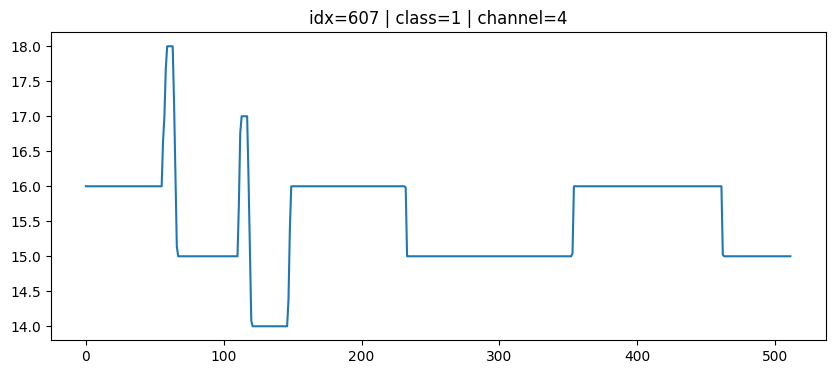

In [11]:
idx = np.random.randint(len(train_dataset))
x,mask,y = train_dataset[idx]
ch = np.random.randint(x.shape[0]) if x.shape[0] > 1 else 0
ts = x[ch].numpy()
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title(f"idx={idx} | class={train_dataset.class_names[y]} | channel={ch}")
plt.show()

In [ ]:
def get_embedding(model, dataloader, device):
    embeddings, labels = [], []
    with torch.no_grad():
        for batch_x, batch_masks, batch_labels in tqdm(dataloader, total=len(dataloader)):
            batch_x = batch_x.to(device, dtype=torch.float32)
            batch_masks = batch_masks.to(device)

            output = model(x_enc=batch_x, input_mask=batch_masks) 
            embedding = output.embeddings
            embeddings.append(embedding.detach().cpu().numpy())
            labels.append(batch_labels)        

    embeddings, labels = np.concatenate(embeddings), np.concatenate(labels)
    return embeddings, labels

In [13]:
VARIANT_TO_MODEL = {
    "small": "AutonLab/MOMENT-1-small",
    "base":  "AutonLab/MOMENT-1-base",
    "large": "AutonLab/MOMENT-1-large",
}

VARIANT_TO_CHECKPOINT = {
    "small": "../data/checkpoints/small/TimeRAN_small.pth",
    "base": "../data/checkpoints/base/TimeRAN_base.pth",
    "large": "../data/checkpoints/large/TimeRAN_large.pth",
}

variant = cfg["variant"].lower()
BACKEND = cfg["backend"]

if variant not in VARIANT_TO_MODEL:
    raise ValueError(f"Unknown variant '{cfg['variant']}'. Choose from {list(VARIANT_TO_MODEL.keys())}")

if BACKEND not in ["TimeRAN", "MOMENT"]:
    raise ValueError("backend must be either 'TimeRAN' or 'MOMENT'")

MODEL_NAME = VARIANT_TO_MODEL[variant]

model = MOMENTPipeline.from_pretrained(
    MODEL_NAME,
    model_kwargs={"task_name": "embedding"}
)

model.init()

if BACKEND == "TimeRAN":
    CHECKPOINT_PATH = VARIANT_TO_CHECKPOINT[variant]
    state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)

    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=False)

elif BACKEND == "MOMENT":
    pass

else:
    raise ValueError(f"Unknown backend: {BACKEND}")

model = model.to(device)

In [14]:
train_embeddings, train_labels = get_embedding(model, train_dataloader, device)
test_embeddings, test_labels = get_embedding(model, test_dataloader, device)

100%|██████████| 67/67 [01:07<00:00,  1.01s/it]


In [15]:
clf = fit_svm(features=train_embeddings, y=train_labels)

y_pred_train = clf.predict(train_embeddings)
y_pred_test = clf.predict(test_embeddings)
train_accuracy = clf.score(train_embeddings, train_labels)
test_accuracy = clf.score(test_embeddings, test_labels)

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

/home/ioannis/miniconda/envs/moment/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ioannis/miniconda/envs/moment/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ioannis/miniconda/envs/moment/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvm

Train accuracy: 1.00
Test accuracy: 1.00


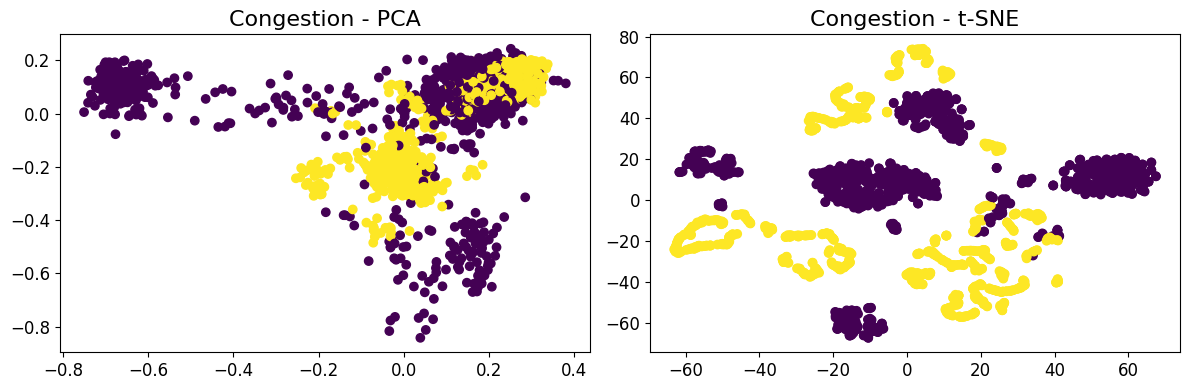

In [16]:
pca_2d = PCA(n_components=2).fit_transform(test_embeddings)

test_embeddings_flat = test_embeddings.reshape(test_embeddings.shape[0], -1)
tsne = TSNE(n_components=2, perplexity=25, learning_rate='auto', init='random')
tsne_2d = tsne.fit_transform(test_embeddings_flat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=test_labels.squeeze())
axes[0].set_title(f'{dataset_cfg["task"]["target"].capitalize()} - PCA', fontsize=16)
axes[0].tick_params(labelsize=12)

axes[1].scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=test_labels.squeeze())
axes[1].set_title(f'{dataset_cfg["task"]["target"].capitalize()} - t-SNE', fontsize=16)
axes[1].tick_params(labelsize=12)

plt.tight_layout()
plt.show()